# Chapter 3.2 EB Flow Matching

**TL;DR** — Moves from the toy CFM mechanism to the main EB timecourse experiment. The reader finishes with EB audit tables, a cached 20D `VelocityMLP`, training logs, PHATE rollout figures, and Euler-step sensitivity diagnostics.

**Prerequisites** - Chapter 3.1 (toy CFM from scratch). The CFM training loop is shown inline in chapter3_1 and reused here.

**Outputs**
- `figures/ch03/figB1_eb20d_train_val_loss.png`
- `figures/ch03/figB1_eb20d_train_val_loss.pdf`
- `figures/ch03/fig03_04_eb_endpoint_pairs_phate.png`
- `figures/ch03/fig03_04_eb_endpoint_pairs_phate.pdf`
- `figures/ch03/fig03_08_eb_population_evolution_phate.png`
- `figures/ch03/fig03_08_eb_population_evolution_phate.pdf`
- `figures/ch03/fig03_09_euler_step_sensitivity_phate.png`
- `figures/ch03/fig03_09_euler_step_sensitivity_phate.pdf`
- `tables/ch03/ch03_eb_timepoint_counts.csv`
- `tables/ch03/ch03_eb20d_train_val_split.csv`
- `tables/ch03/ch03_eb20d_training_log.csv`
- `tables/ch03/ch03_euler_step_sensitivity.csv`
- `outputs/ch03/ch03_eb20d_velocity_mlp_seed42.pt`
- `outputs/ch03/ch03_eb20d_main_config_seed42.json`

**Runtime** - `QUICK_MODE` defaults on through the shared Chapter 3 config and shortens EB training and plotting workloads; `SMOKE_MODE` further shrinks training and sampling for CI. On CPU, quick mode can still take several minutes because it trains the EB `VelocityMLP`; use smoke mode for structural checks.

**Key parameters**
- `SEED` defaults to `42` via `CH03_SEED` and is embedded in the model/cache filenames.
- `QUICK_MODE` defaults to `CH03_QUICK=1`; `SMOKE_MODE` uses `CH03_SMOKE_MODE=1`.
- State and training space: standardized EB `PC-20`; PHATE is display-only.
- `TRAIN_STEPS`, `BATCH_SIZE`, and `VALIDATION_BATCH_SIZE` come from the Chapter 3 run config used in the training cell.
- Euler sensitivity uses `euler_Ks = [1, 2, 5, 10, 20, 50, 100, 200]`.
- `pair_plot_n = 80` in quick mode, otherwise `120`.

## Tutorial setup

The setup keeps infrastructure out of the scientific sections: project-root discovery, deterministic seeds, output directories, plotting style, and a compact save-and-display helper. The method code appears in the CFM objective and training sections below.


In [1]:
from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

try:
    import torch
except ImportError as exc:
    raise ImportError("This notebook requires PyTorch for CFM training and sampling.") from exc

import sys

ROOT_HINT = Path.cwd().resolve()
if not (ROOT_HINT / "src").is_dir():
    ROOT_HINT = ROOT_HINT.parent
if str(ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(ROOT_HINT))

from src.tutorial_init import apply_tutorial_plot_style, bootstrap, make_ch03_run_config, make_save_and_show

SEED = int(os.environ.get("CH03_SEED", "42"))
QUICK_MODE = os.environ.get("CH03_QUICK", "1") == "1"
boot = bootstrap(chapter="ch03", seed=SEED, quick_mode=QUICK_MODE)
PROJECT_ROOT = boot.project_root
FIG_DIR = boot.fig_dir
OUT_DIR = boot.out_dir
DEVICE = boot.device

from src.visualization import flow_matching as ch03
from src.utils import set_seed
from src.core.models import VelocityMLP, count_parameters
from src.data.loading import load_eb_timecourse_for_ch03, copy_trajectorynet_eb_to_data
from src.evaluation.metrics import mmd_rbf, sliced_wasserstein_distance


project_root=..
seed=42
quick_mode=True
fig_dir=figures/ch03
out_dir=outputs/ch03
device=cuda


In [2]:
config = make_ch03_run_config()
SEED = config.seed
QUICK_MODE = config.quick_mode
SMOKE_MODE = config.smoke_mode
PAPER_FIGURE_MODE = config.paper_figure_mode
DEVICE = config.device
rng = np.random.default_rng(SEED)

context = ch03.make_ch03_context(PROJECT_ROOT)
FIG_DIR = context.fig_dir
TABLE_DIR = context.table_dir
OUT_DIR = context.output_dir
PAPER_COLORS = ch03.PAPER_COLORS

apply_tutorial_plot_style()
save_and_show = make_save_and_show(FIG_DIR, write_pdf=PAPER_FIGURE_MODE, save_fn=ch03.save_and_close_figure)

set_paper_style = apply_tutorial_plot_style
add_panel_label = ch03.add_panel_label
short_strategy_label = ch03.short_strategy_label
clean_spines = ch03.clean_spines
format_metric_axis = ch03.format_metric_axis
add_note = ch03.add_note
as_np = ch03.as_np
subsample_idx = ch03.subsample_idx
robust_limits = ch03.robust_limits
format_axis = ch03.format_axis

print(
    f"project_root={PROJECT_ROOT}; device={DEVICE}; seed={SEED}; "
    f"quick_mode={QUICK_MODE}; smoke_mode={SMOKE_MODE}"
)


project_root=/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_single_cell_dynamic_biology; device=cuda; seed=42; quick_mode=True; smoke_mode=False


## 1. Data audit

The EB main experiment uses `load_eb_timecourse_for_ch03`, which returns 20D PC coordinates as `X_cost`, 2D PHATE coordinates as `X_plot`, and snapshot labels as `time`. The model, CFM loss, MMD, and Sliced W2 all use 20D PC space; PHATE is display-only. The code prints the three array shapes as a compact audit, then the timepoint-count table records how many cells are available and selected per snapshot.


In [3]:
EB_PATH = PROJECT_ROOT / "data" / "trajectorynet_eb" / "eb_velocity_v5.npz"
EB_SOURCE_PATH = PROJECT_ROOT.parent / "baselines" / "trajectorynet" / "data" / "eb_velocity_v5.npz"
if not EB_PATH.exists():
    print(f"{EB_PATH} not found; attempting copy from {EB_SOURCE_PATH}")
    copy_trajectorynet_eb_to_data(source_path=EB_SOURCE_PATH, target_path=EB_PATH)

max_cells_per_time = 750 if QUICK_MODE else 1800
if SMOKE_MODE:
    max_cells_per_time = 90

eb = load_eb_timecourse_for_ch03(
    EB_PATH,
    cost_embedding="pcs",
    plot_embedding="phate",
    n_cost_dims=20,
    max_cells_per_time=max_cells_per_time,
    seed=SEED,
)

print(
    f"X_cost shape={tuple(eb['X_cost'].shape)}; "
    f"X_plot shape={tuple(eb['X_plot'].shape)}; "
    f"time shape={tuple(eb['time'].shape)}"
)


X_cost shape=(3750, 20); X_plot shape=(3750, 2); time shape=(3750,)


In [4]:
selected_counts = pd.Series(eb["time"], name="time").value_counts().sort_index().rename_axis("time").reset_index(name="selected_n_cells")
count_table = eb["full_counts_by_time"].merge(selected_counts, on="time", how="left")
count_table["selected_n_cells"] = count_table["selected_n_cells"].fillna(0).astype(int)
ch03.save_csv(TABLE_DIR / "ch03_eb_timepoint_counts.csv", count_table)
ch03.display_table(count_table[["time", "n_cells", "selected_n_cells"]], n=8)


,time,n_cells,selected_n_cells
0,0,2381,750
1,1,4163,750
2,2,3278,750
3,3,3665,750
4,4,3332,750


,time,n_cells,selected_n_cells
0,0,2381,750
1,1,4163,750
2,2,3278,750
3,3,3665,750
4,4,3332,750


In [5]:
time_labels = sorted(pd.Series(eb["time"]).unique(), key=lambda x: int(x) if str(x).isdigit() else str(x))
if len(time_labels) < 2:
    raise ValueError(f"Need at least two EB time labels; found {time_labels}")
source_time = str(time_labels[0])
target_time = str(time_labels[1])

mask_source = eb["time"].astype(str) == source_time
mask_target = eb["time"].astype(str) == target_time
X_source_20d = np.asarray(eb["X_cost"][mask_source], dtype=np.float32)
X_target_20d = np.asarray(eb["X_cost"][mask_target], dtype=np.float32)
X_source_phate = np.asarray(eb["X_plot"][mask_source], dtype=np.float32)
X_target_phate = np.asarray(eb["X_plot"][mask_target], dtype=np.float32)
cell_source = np.asarray(eb["cell_id"])[mask_source]
cell_target = np.asarray(eb["cell_id"])[mask_target]

assert X_source_20d.shape[1] == 20 and X_target_20d.shape[1] == 20
assert X_source_phate.shape[1] == 2 and X_target_phate.shape[1] == 2
endpoint_audit = pd.DataFrame([
    {"population": "source", "time": source_time, "X_20d_shape": tuple(X_source_20d.shape), "X_phate_shape": tuple(X_source_phate.shape)},
    {"population": "target", "time": target_time, "X_20d_shape": tuple(X_target_20d.shape), "X_phate_shape": tuple(X_target_phate.shape)},
])
ch03.display_table(endpoint_audit, n=2)


,population,time,X_20d_shape,X_phate_shape
0,source,0,"(750, 20)","(750, 2)"
1,target,1,"(750, 20)","(750, 2)"


,population,time,X_20d_shape,X_phate_shape
0,source,0,"(750, 20)","(750, 2)"
1,target,1,"(750, 20)","(750, 2)"


## 2. Train/validation split

The split is by cells, not by generated endpoint pairs. Source cells are split 80/20, target cells are split 80/20, training pairs draw only from train pools, and validation pairs draw only from held-out pools. The split CSV is the durable audit artifact; the notebook prints the same train/validation counts inline.


In [6]:
src_train_idx, src_val_idx = ch03.train_val_indices(len(X_source_20d), seed=SEED + 10)
tgt_train_idx, tgt_val_idx = ch03.train_val_indices(len(X_target_20d), seed=SEED + 11)

X0_train = X_source_20d[src_train_idx]
X1_train = X_target_20d[tgt_train_idx]
X0_val = X_source_20d[src_val_idx]
X1_val = X_target_20d[tgt_val_idx]
X0_train_phate = X_source_phate[src_train_idx]
X1_train_phate = X_target_phate[tgt_train_idx]
X0_val_phate = X_source_phate[src_val_idx]
X1_val_phate = X_target_phate[tgt_val_idx]

split_table = pd.DataFrame([
    {"population": "source", "time": source_time, "train_cells": len(X0_train), "val_cells": len(X0_val)},
    {"population": "target", "time": target_time, "train_cells": len(X1_train), "val_cells": len(X1_val)},
])
ch03.save_csv(TABLE_DIR / "ch03_eb20d_train_val_split.csv", split_table)
print(
    f"source train/val={len(X0_train)}/{len(X0_val)} cells; "
    f"target train/val={len(X1_train)}/{len(X1_val)} cells"
)


source train/val=600/150 cells; target train/val=600/150 cells


## 3. Endpoint pairing

Training pairs draw fresh independent source and target endpoints each batch from the training pools. Validation uses a fixed held-out endpoint-pair set and fixed interpolation times, so validation curves are deterministic across logging events.


In [7]:
pair_batch_fn = ch03.make_random_pair_batch_fn(X0_train, X1_train, seed=SEED + 12)

val_pair_n = 1200 if QUICK_MODE else 2500
if SMOKE_MODE:
    val_pair_n = 180
val_pair_rng = np.random.default_rng(SEED + 13)
val_i0 = val_pair_rng.integers(0, len(X0_val), size=int(val_pair_n))
val_i1 = val_pair_rng.integers(0, len(X1_val), size=int(val_pair_n))
val_x0 = X0_val[val_i0].astype(np.float32)
val_x1 = X1_val[val_i1].astype(np.float32)
val_t_grid = np.asarray([0.25, 0.50, 0.75], dtype=np.float32)

print(
    f"Training pairs draw fresh independent endpoints from pools "
    f"source={len(X0_train)}, target={len(X1_train)}. "
    f"Validation uses {val_pair_n} fixed held-out pairs from pools "
    f"source={len(X0_val)}, target={len(X1_val)}."
)


Training pairs draw fresh independent endpoints from pools source=600, target=600. Validation uses 1200 fixed held-out pairs from pools source=150, target=150.


The CFM objective below is the same local velocity regression introduced in Chapter 3.1, now applied in 20D PC space. For an independent endpoint pair `(x0, x1)` and time `t`, the model sees `x_t=(1-t)x0+t*x1` and regresses the constant conditional velocity `x1-x0`; training never integrates an ODE.


In [8]:
def make_cfm_batch(x0, x1):
    if x0.shape != x1.shape:
        raise ValueError(f"x0 and x1 must match, got {tuple(x0.shape)} and {tuple(x1.shape)}")
    t = torch.rand(x0.shape[0], 1, device=x0.device, dtype=x0.dtype)
    x_t = (1.0 - t) * x0 + t * x1
    target_velocity = x1 - x0
    return {"x_t": x_t, "t": t, "target_velocity": target_velocity}


def cfm_loss_from_batch(model, batch):
    pred_velocity = model(batch["x_t"], batch["t"])
    return ((pred_velocity - batch["target_velocity"]) ** 2).mean(dim=-1).mean()


@torch.no_grad()
def euler_rollout(model, x0, n_steps, *, return_traj=True):
    n_steps = int(n_steps)
    if n_steps <= 0:
        raise ValueError("n_steps must be positive")
    x = x0
    traj = [x0] if return_traj else None
    times = torch.linspace(0.0, 1.0, n_steps + 1, device=x0.device, dtype=x0.dtype)
    for step in range(n_steps):
        t = torch.full((x.shape[0], 1), times[step], device=x.device, dtype=x.dtype)
        dt = times[step + 1] - times[step]
        velocity = model(x, t)
        x = x + dt * velocity
        if return_traj:
            traj.append(x)
    if return_traj:
        return x, torch.stack(traj, dim=0), n_steps
    return x, None, n_steps


## 4. Model config

The EB model is trained in 20D PC space using `VelocityMLP(x_dim=20, hidden_dim=256, hidden_layers=4)`. PHATE coordinates do not appear in the model input, target velocity, validation loss, or saved checkpoint.


In [9]:
set_seed(SEED + 20)
eb_model = VelocityMLP(x_dim=20, hidden_dim=256, hidden_layers=4).to(DEVICE)
optimizer = torch.optim.Adam(eb_model.parameters(), lr=1e-3)

eb_steps = 1500 if QUICK_MODE else 10000
if SMOKE_MODE:
    eb_steps = 45
eb_batch_size = 256
if SMOKE_MODE:
    eb_batch_size = 96
log_every = 100 if not SMOKE_MODE else 10

print(
    f"VelocityMLP: x_dim=20, hidden_dim=256, hidden_layers=4, "
    f"parameters={count_parameters(eb_model)}, steps={eb_steps}, "
    f"batch_size={eb_batch_size}, log_every={log_every}, device={DEVICE}"
)


VelocityMLP: x_dim=20, hidden_dim=256, hidden_layers=4, parameters=208148, steps=1500, batch_size=256, log_every=100, device=cuda


## 5. Training loop

This is the core EB CFM experiment. The loop is explicit because the objective, held-out validation call, logging cadence, and wall-clock accounting are part of the scientific method.


In [10]:
eb_val_eval_pairs = 1200 if not SMOKE_MODE else 180
print(
    f"Validation uses {len(val_x0)} fixed held-out pairs, "
    f"t_grid={val_t_grid.tolist()}, max_eval_pairs_per_log={eb_val_eval_pairs}."
)


Validation uses 1200 fixed held-out pairs, t_grid=[0.25, 0.5, 0.75], max_eval_pairs_per_log=1200.


In [11]:
rows = []
eb_model.train()
start = time.perf_counter()
last_log_step = 0
last_log_time = start
for step in range(1, eb_steps + 1):
    batch_np = pair_batch_fn(eb_batch_size)
    x0 = torch.as_tensor(batch_np["x0"], dtype=torch.float32, device=DEVICE)
    x1 = torch.as_tensor(batch_np["x1"], dtype=torch.float32, device=DEVICE)
    batch = make_cfm_batch(x0, x1)
    loss = cfm_loss_from_batch(eb_model, batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step == 1 or step % log_every == 0 or step == eb_steps:
        now = time.perf_counter()
        val_mse = ch03.val_cfm_mse(
            eb_model,
            val_x0,
            val_x1,
            val_t_grid,
            device=DEVICE,
            max_eval_pairs=eb_val_eval_pairs,
            seed=SEED + 14,
        )
        rows.append({
            "step": int(step),
            "train_loss_20d": float(loss.detach().cpu()),
            "val_mse_20d_fixed_t_grid": float(val_mse),
            "wall_time_sec": float(now - start),
            "sec_per_step_since_last_log": float((now - last_log_time) / max(1, step - last_log_step)),
            "batch_size": int(eb_batch_size),
            "x_dim": 20,
            "hidden_dim": 256,
            "hidden_layers": 4,
            "n_parameters": count_parameters(eb_model),
            "device": DEVICE,
        })
        last_log_step = step
        last_log_time = now

eb_history = pd.DataFrame(rows)
ch03.save_csv(TABLE_DIR / "ch03_eb20d_training_log.csv", eb_history)
print({"logged_rows": len(eb_history), "final_step": int(eb_history["step"].iloc[-1])})


{'logged_rows': 16, 'final_step': 1500}


## 6. Loss table

The training log is saved as the EB main loss table. Previewing the final rows makes the optimization scale and validation trend visible before plotting.


In [12]:
loss_preview_columns = [
    "step",
    "train_loss_20d",
    "val_mse_20d_fixed_t_grid",
    "wall_time_sec",
    "sec_per_step_since_last_log",
]
ch03.display_table(eb_history.tail(6), columns=loss_preview_columns, n=6)


,step,train_loss_20d,val_mse_20d_fixed_t_grid,wall_time_sec,sec_per_step_since_last_log
10,1000,4.116707,4.802918,5.463022,0.005475
11,1100,4.401233,4.977775,6.008002,0.005450
12,1200,4.046910,4.990877,6.554545,0.005465
13,1300,3.968097,4.979888,7.104368,0.005498
14,1400,3.885123,4.993577,7.656674,0.005523
15,1500,4.193732,5.081516,8.197396,0.005407


,step,train_loss_20d,val_mse_20d_fixed_t_grid,wall_time_sec,sec_per_step_since_last_log
10,1000,4.116707,4.802918,5.463022,0.005475
11,1100,4.401233,4.977775,6.008002,0.005450
12,1200,4.046910,4.990877,6.554545,0.005465
13,1300,3.968097,4.979888,7.104368,0.005498
14,1400,3.885123,4.993577,7.656674,0.005523
15,1500,4.193732,5.081516,8.197396,0.005407


## 7. Loss figure

Figure B1 is the saved train/validation CFM loss curve. It is displayed from the saved PNG so a freshly executed notebook shows the same artifact that downstream paper checks read.


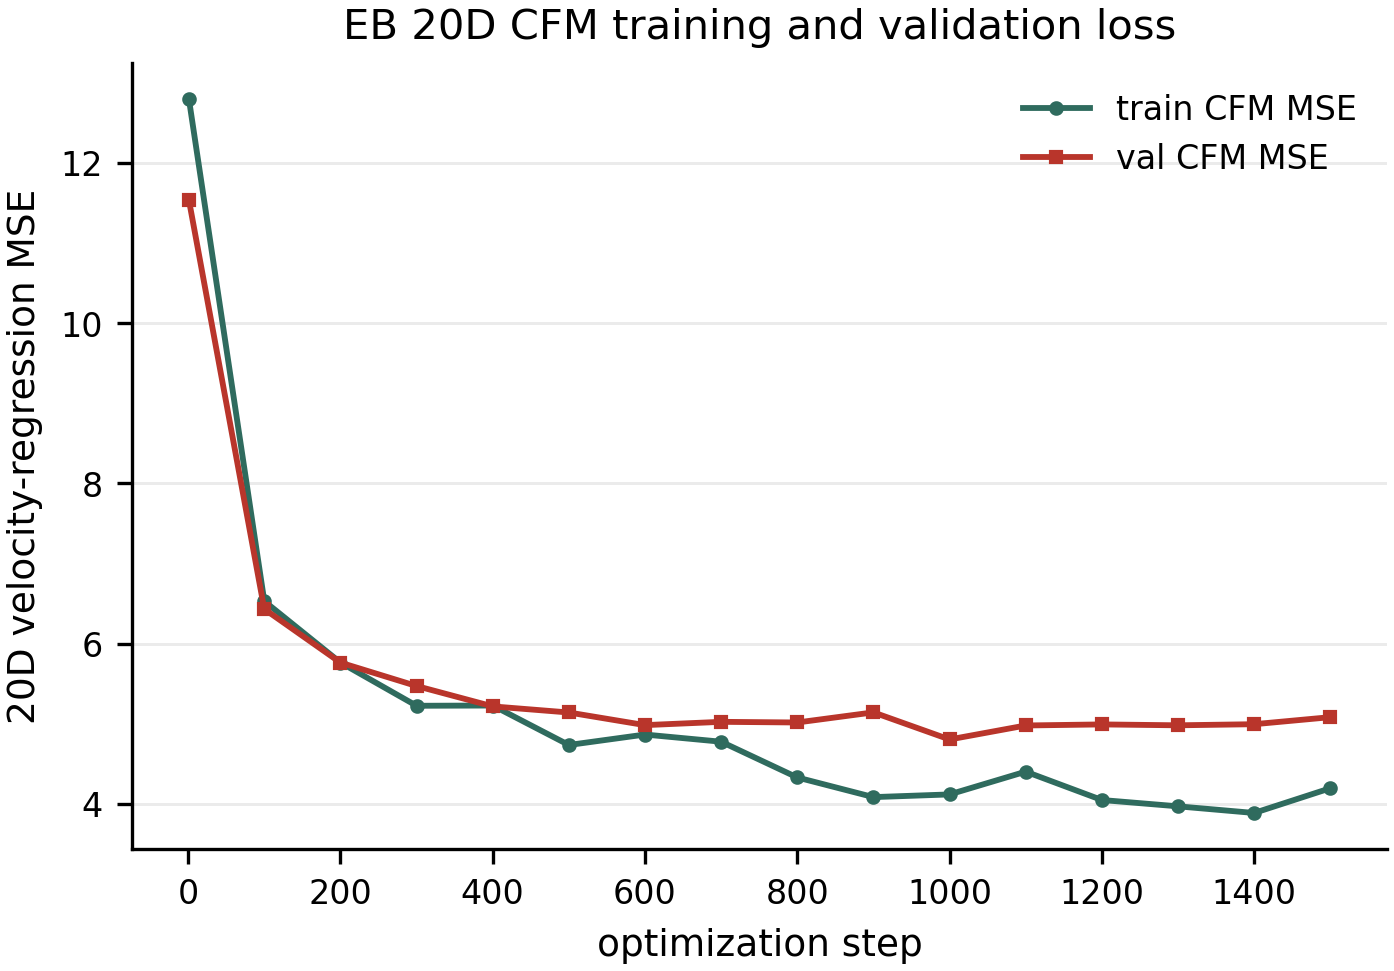

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_single_cell_dynamic_biology/figures/ch03/figB1_eb20d_train_val_loss.png')

In [13]:
fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.plot(eb_history["step"], eb_history["train_loss_20d"], marker="o", markersize=2.5, linewidth=1.4, color="#2F6B5E", label="train CFM MSE")
ax.plot(eb_history["step"], eb_history["val_mse_20d_fixed_t_grid"], marker="s", markersize=2.5, linewidth=1.4, color="#B9352B", label="val CFM MSE")
ax.set_xlabel("optimization step")
ax.set_ylabel("20D velocity-regression MSE")
ax.set_title("EB 20D CFM training and validation loss")
ax.grid(axis="y", color="0.92", linewidth=0.7)
ax.legend(frameon=False)
save_and_show(fig, "figB1_eb20d_train_val_loss.png", width=650)


## 8. Model cache

Chapter 3.3 reads the exact model and config names below. The default seed remains 42, so the default cache filenames stay `ch03_eb20d_velocity_mlp_seed42.pt` and `ch03_eb20d_main_config_seed42.json`.


In [14]:
DEFAULT_MAIN_MODEL_ARTIFACT = "ch03_eb20d_velocity_mlp_seed42.pt"
DEFAULT_MAIN_CONFIG_ARTIFACT = "ch03_eb20d_main_config_seed42.json"
MAIN_MODEL_PATH = OUT_DIR / f"ch03_eb20d_velocity_mlp_seed{SEED}.pt"
MAIN_CONFIG_PATH = OUT_DIR / f"ch03_eb20d_main_config_seed{SEED}.json"
torch.save(eb_model.state_dict(), MAIN_MODEL_PATH)
main_model_config = {
    "seed": SEED,
    "quick_mode": QUICK_MODE,
    "smoke_mode": SMOKE_MODE,
    "x_dim": 20,
    "hidden_dim": 256,
    "hidden_layers": 4,
    "steps": int(eb_steps),
    "batch_size": int(eb_batch_size),
    "source_time": source_time,
    "target_time": target_time,
    "model_path": str(MAIN_MODEL_PATH.relative_to(PROJECT_ROOT)),
}
ch03.save_json(MAIN_CONFIG_PATH, main_model_config)
print(
    "Cached EB model artifacts: "
    f"{MAIN_MODEL_PATH.relative_to(PROJECT_ROOT)}; {MAIN_CONFIG_PATH.relative_to(PROJECT_ROOT)}"
)


Cached EB model artifacts: outputs/ch03/ch03_eb20d_velocity_mlp_seed42.pt; outputs/ch03/ch03_eb20d_main_config_seed42.json


## 9. Endpoint pair visualization

This section draws sampled train endpoint pairs in PHATE 2D for interpretability. The CFM training paths are straight lines in 20D PC space; their PHATE-projected line segments are visualization-only chords.


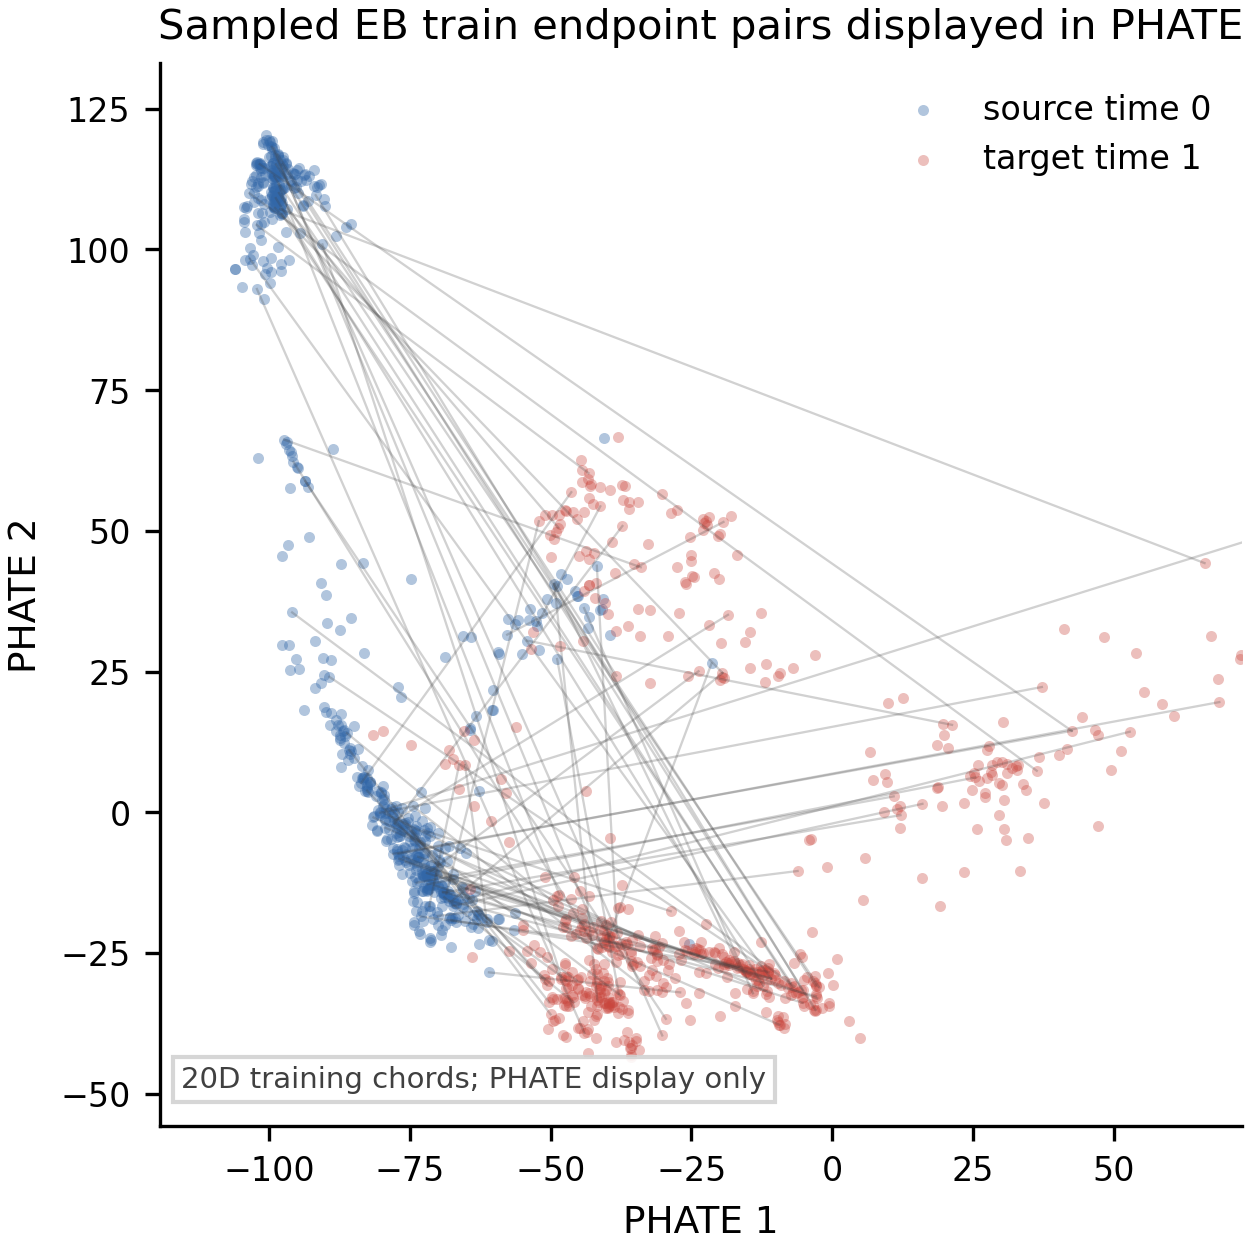

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_single_cell_dynamic_biology/figures/ch03/fig03_04_eb_endpoint_pairs_phate.png')

In [15]:
pair_plot_n = 80 if QUICK_MODE else 120
if SMOKE_MODE:
    pair_plot_n = 35
fig = ch03.plot_endpoint_pairs_phate(
    X0_train_phate,
    X1_train_phate,
    n_pairs=pair_plot_n,
    seed=SEED + 30,
    source_time=source_time,
    target_time=target_time,
)
save_and_show(fig, "fig03_04_eb_endpoint_pairs_phate.png", width=650)


## 10. Sampling and population evolution

This section integrates the learned velocity field in 20D PC space with the fixed-step Euler sampler defined above. Generated 20D states are projected to PHATE-like coordinates only for visualization.


In [16]:
from sklearn.neighbors import KNeighborsRegressor

knn_neighbors = min(20, len(eb["X_cost"]))
phate_projector = KNeighborsRegressor(n_neighbors=knn_neighbors, weights="distance")
phate_projector.fit(np.asarray(eb["X_cost"], dtype=np.float32), np.asarray(eb["X_plot"], dtype=np.float32))

sample_n = min(1200 if QUICK_MODE else 2200, len(X0_val))
if SMOKE_MODE:
    sample_n = min(150, len(X0_val))
sample_idx = subsample_idx(len(X0_val), sample_n, seed=SEED + 31)
x0_eval_20d = torch.as_tensor(X0_val[sample_idx], dtype=torch.float32, device=DEVICE)
print(f"Sampling {sample_n} held-out source cells in 20D PC space; PHATE display uses kNN k={knn_neighbors}.")


Sampling 150 held-out source cells in 20D PC space; PHATE display uses kNN k=20.


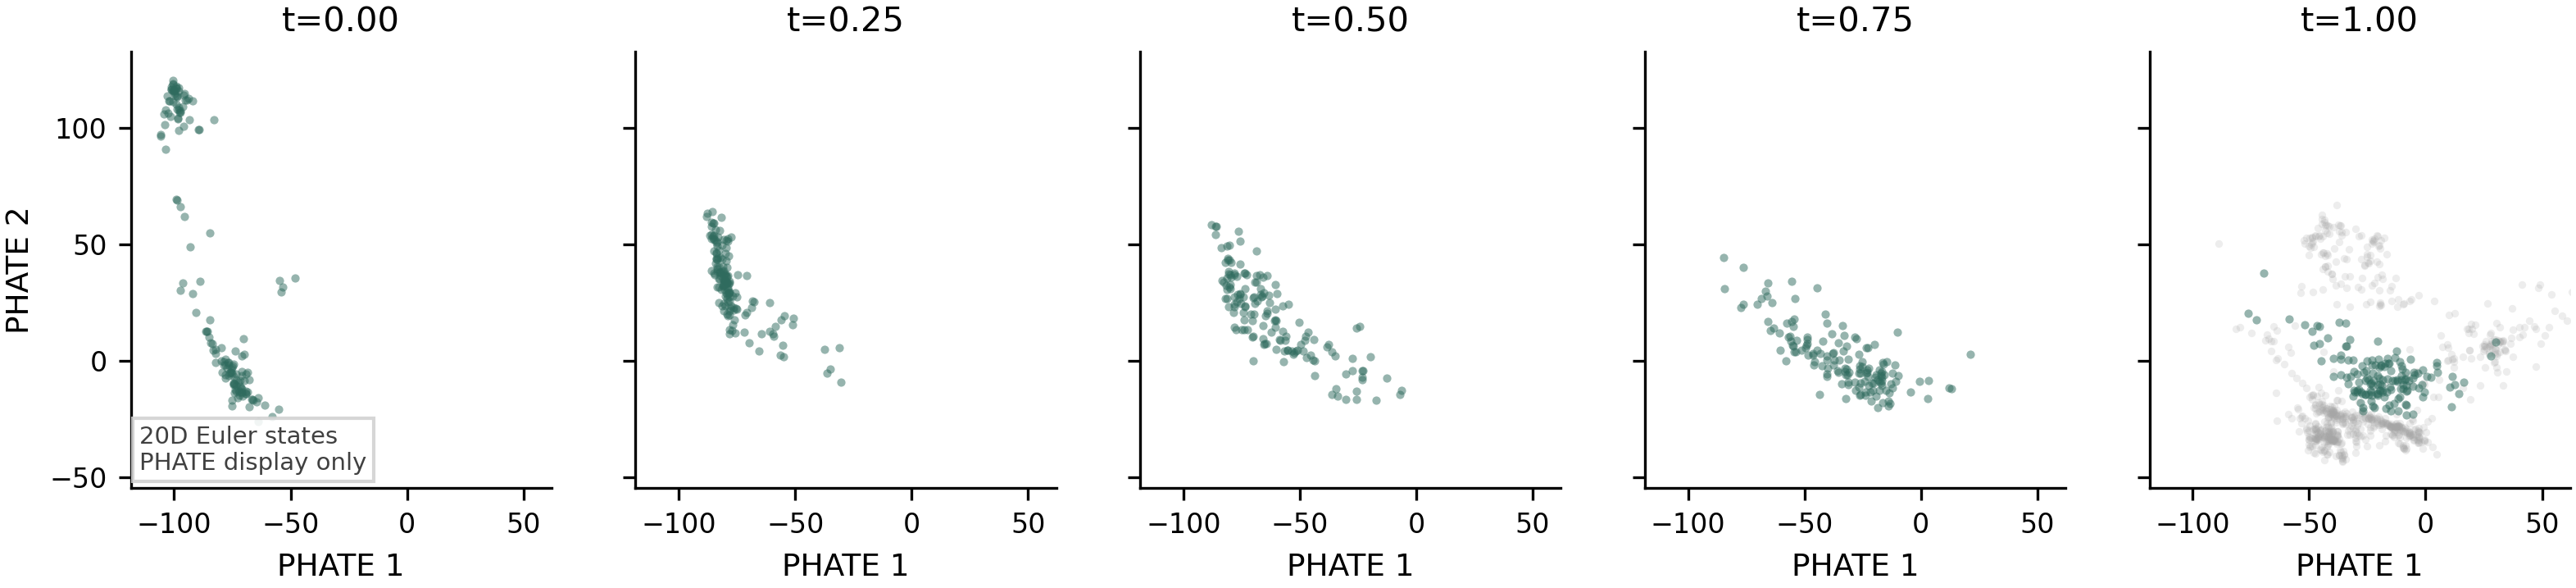

{'euler_nfe': 100, 'trajectory_shape': (101, 150, 20)}


In [17]:
eb_model.eval()
euler_population_steps = 100 if not SMOKE_MODE else 25
eb_final_20d_t, eb_traj_20d_t, eb_nfe = euler_rollout(eb_model, x0_eval_20d, n_steps=euler_population_steps, return_traj=True)
eb_traj_20d = as_np(eb_traj_20d_t)
eb_final_20d = as_np(eb_final_20d_t)

show_times = [0.0, 0.25, 0.5, 0.75, 1.0]
show_steps = np.round(np.asarray(show_times) * (eb_traj_20d.shape[0] - 1)).astype(int)
generated_phate_by_time = [phate_projector.predict(eb_traj_20d[step]) for step in show_steps]

xlim, ylim = robust_limits(X_source_phate, X_target_phate, *generated_phate_by_time, margin=0.10)
fig, axes = plt.subplots(1, 5, figsize=(12.8, 2.85), sharex=True, sharey=True)
for ax, tau, gen_plot in zip(axes, show_times, generated_phate_by_time):
    if tau == 1.0:
        tidx = subsample_idx(len(X_target_phate), 800, seed=101)
        ax.scatter(X_target_phate[tidx, 0], X_target_phate[tidx, 1], s=5, color="0.65", alpha=0.20, linewidths=0, label="real target")
    ax.scatter(gen_plot[:, 0], gen_plot[:, 1], s=6, color="#2F6B5E", alpha=0.50, linewidths=0, label="generated")
    format_axis(ax, xlim, ylim, xlabel="PHATE 1", ylabel="PHATE 2", title=f"t={tau:.2f}")
    if ax is not axes[0]:
        ax.set_ylabel("")
add_note(axes[0], "20D Euler states\nPHATE display only", loc="lower left")
save_and_show(fig, "fig03_08_eb_population_evolution_phate.png", width=900)
print({"euler_nfe": eb_nfe, "trajectory_shape": eb_traj_20d.shape})


## 11. Euler step sensitivity

This section fixes the trained 20D EB model and varies the Euler step count. CSV metrics are computed in 20D: MMD to a fine-step reference, endpoint MMD to held-out target cells, and Sliced W2 to held-out target cells.


In [18]:
euler_Ks = [1, 2, 5, 10, 20, 50, 100, 200]
reference_K = 200 if QUICK_MODE else 500
if SMOKE_MODE:
    euler_Ks = [1, 2, 5, 10, 20]
    reference_K = 20

ref_endpoint_t, _, ref_nfe = euler_rollout(eb_model, x0_eval_20d, n_steps=reference_K, return_traj=False)
ref_endpoint_20d = as_np(ref_endpoint_t)

target_eval_20d = X1_val.astype(np.float32)
euler_rows = []
euler_panels = []
for K in euler_Ks:
    tic = time.perf_counter()
    endpoint_t, _, nfe = euler_rollout(eb_model, x0_eval_20d, n_steps=K, return_traj=False)
    wall = time.perf_counter() - tic
    endpoint_20d = as_np(endpoint_t)
    projected = phate_projector.predict(endpoint_20d)
    euler_panels.append({"K": K, "nfe": nfe, "endpoint_20d": endpoint_20d, "endpoint_phate": projected})
    euler_rows.append({
        "solver": "euler",
        "K": int(K),
        "nfe": int(nfe),
        "reference_K": int(reference_K),
        "wall_time_sec": float(wall),
        "mmd_20d_to_reference": float(mmd_rbf(endpoint_20d, ref_endpoint_20d)),
        "endpoint_mmd_20d_to_target_val": float(mmd_rbf(endpoint_20d, target_eval_20d)),
        "sliced_w2_20d_to_target_val": float(sliced_wasserstein_distance(endpoint_20d, target_eval_20d, n_projections=128 if not SMOKE_MODE else 48, seed=SEED + K)),
    })

euler_table = pd.DataFrame(euler_rows)
ch03.save_csv(TABLE_DIR / "ch03_euler_step_sensitivity.csv", euler_table)
ch03.display_table(euler_table, n=10)


,solver,K,nfe,reference_K,wall_time_sec,mmd_20d_to_reference,endpoint_mmd_20d_to_target_val,sliced_w2_20d_to_target_val
0,euler,1,1,200,0.000471,0.124219,0.137168,1.238736
1,euler,2,2,200,0.001789,0.027548,0.041918,0.908578
2,euler,5,5,200,0.003523,0.004090,0.019753,0.725082
3,euler,10,10,200,0.005181,0.000991,0.016808,0.743776
4,euler,20,20,200,0.009569,0.000227,0.015914,0.697231
5,euler,50,50,200,0.023435,0.000026,0.015534,0.700736
6,euler,100,100,200,0.088606,0.000003,0.015432,0.732942
7,euler,200,200,200,0.069974,0.000000,0.015384,0.652809


,solver,K,nfe,reference_K,wall_time_sec,mmd_20d_to_reference,endpoint_mmd_20d_to_target_val,sliced_w2_20d_to_target_val
0,euler,1,1,200,0.000471,0.124219,0.137168,1.238736
1,euler,2,2,200,0.001789,0.027548,0.041918,0.908578
2,euler,5,5,200,0.003523,0.004090,0.019753,0.725082
3,euler,10,10,200,0.005181,0.000991,0.016808,0.743776
4,euler,20,20,200,0.009569,0.000227,0.015914,0.697231
5,euler,50,50,200,0.023435,0.000026,0.015534,0.700736
6,euler,100,100,200,0.088606,0.000003,0.015432,0.732942
7,euler,200,200,200,0.069974,0.000000,0.015384,0.652809


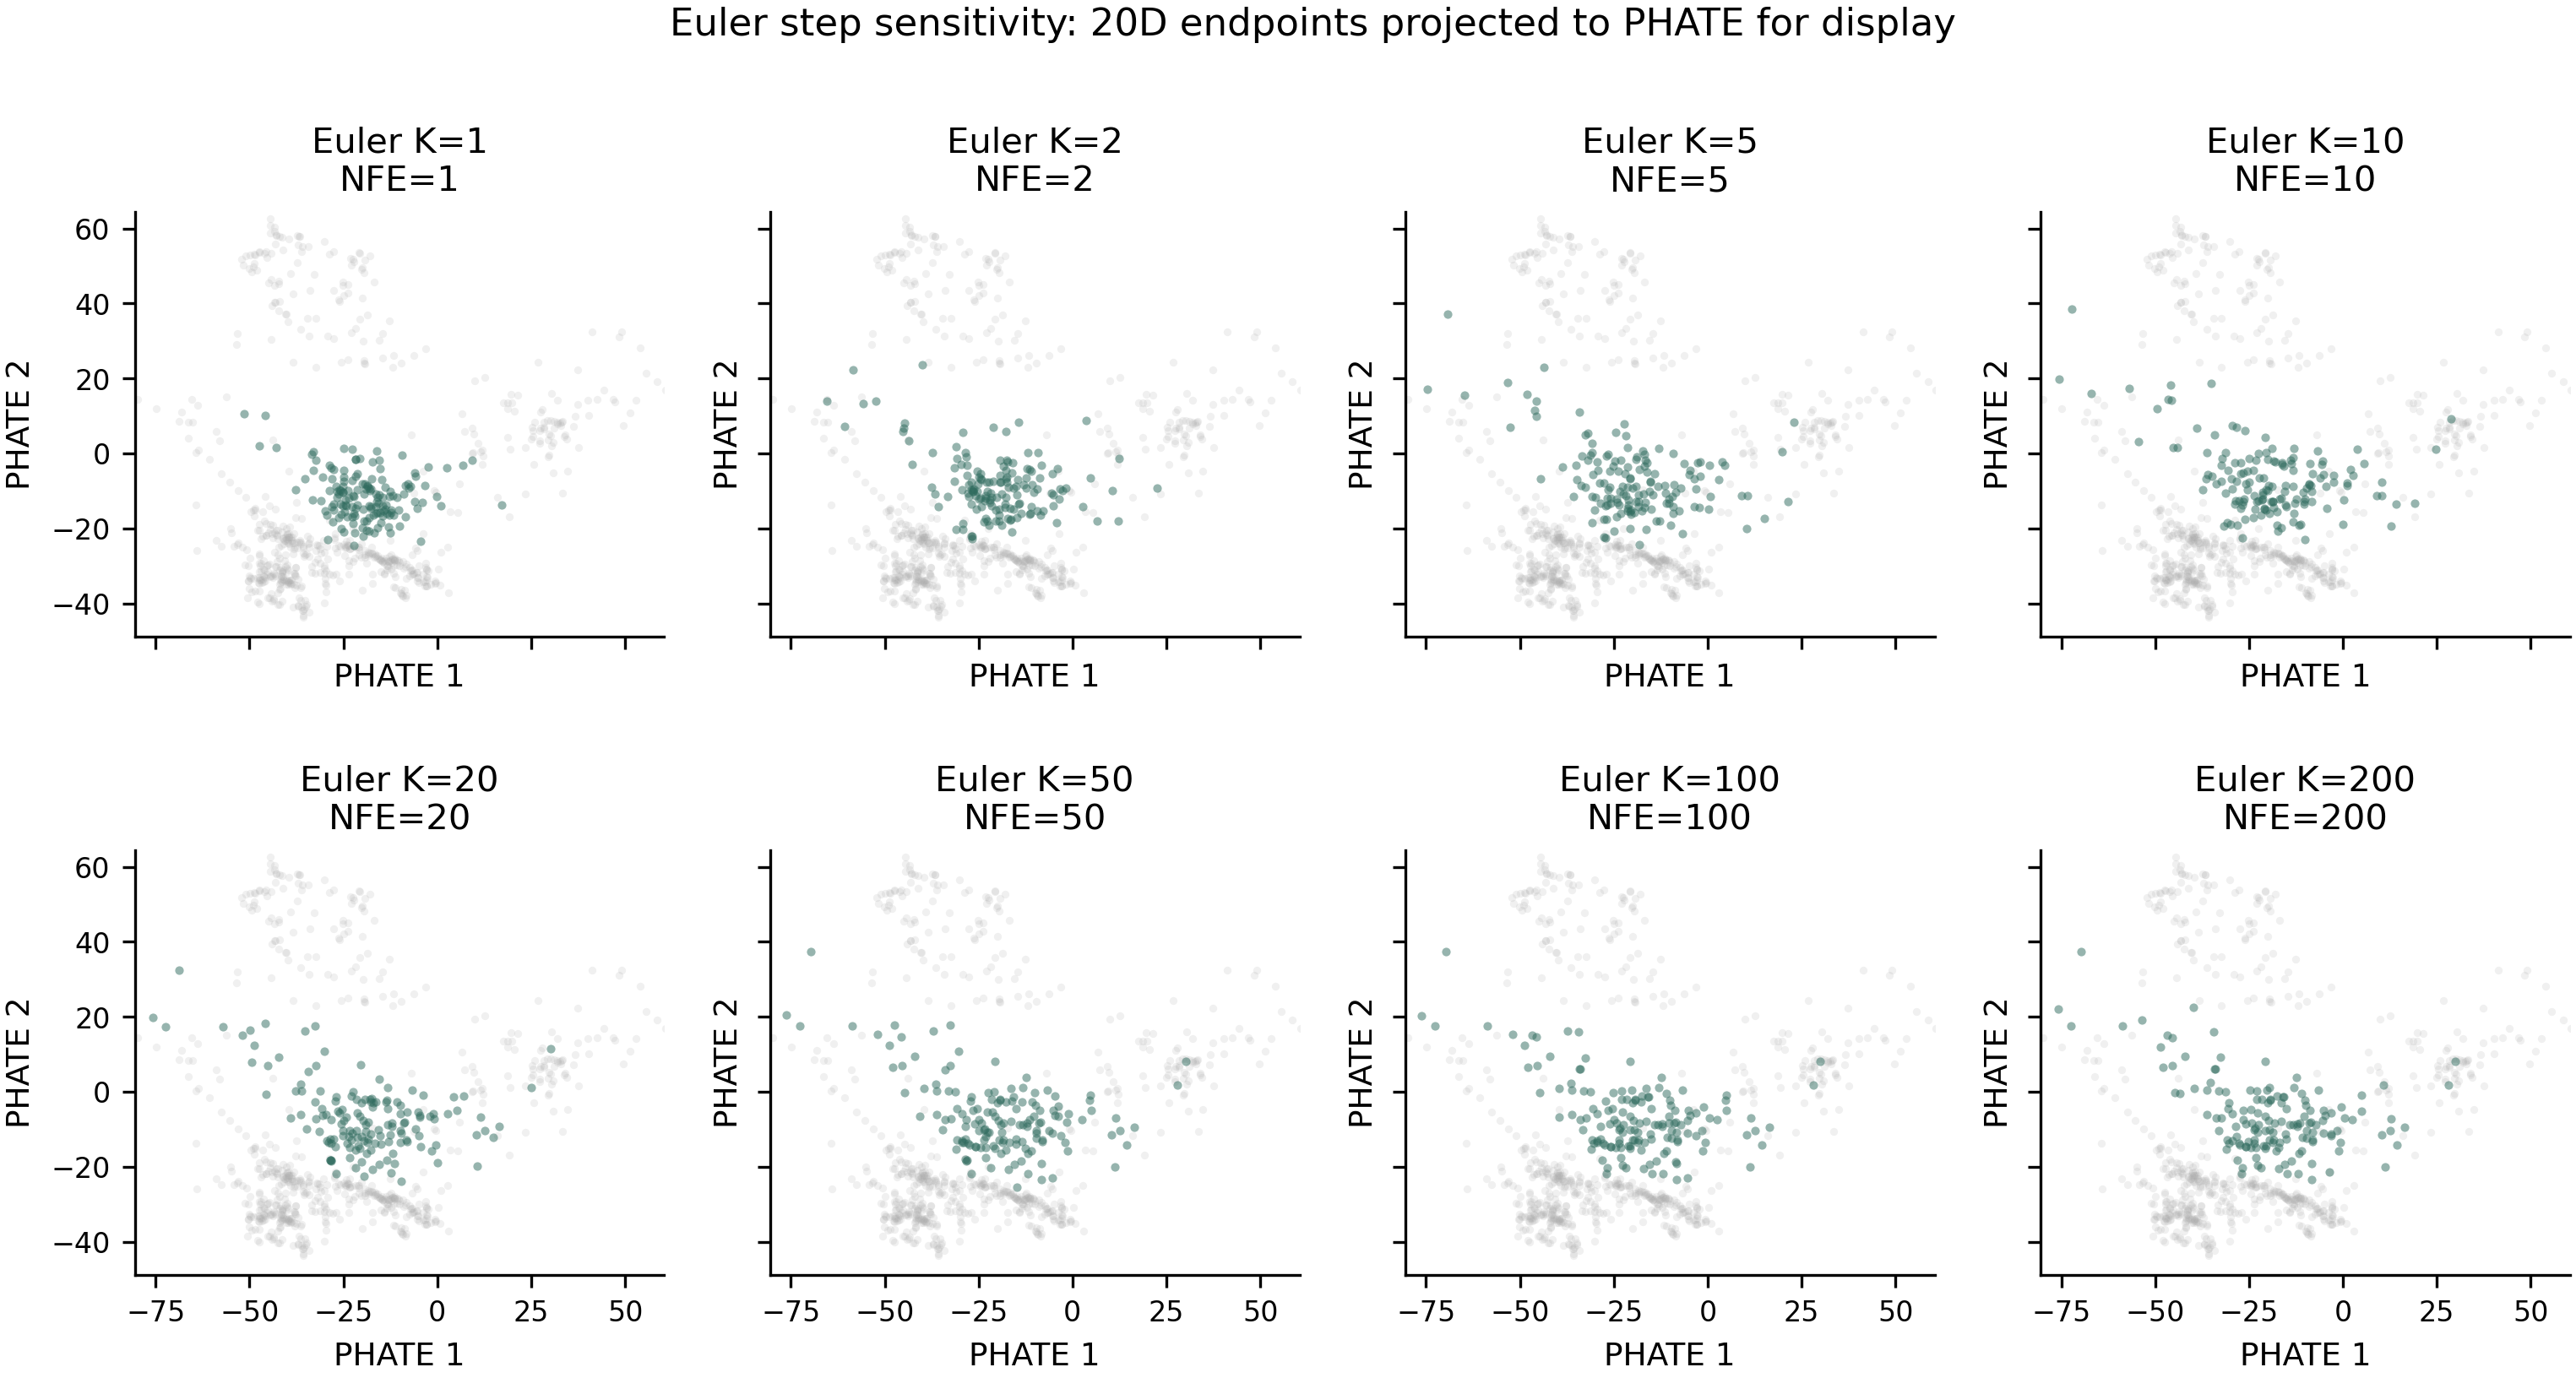

PosixPath('/import/macyang_home4/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_single_cell_dynamic_biology/figures/ch03/fig03_09_euler_step_sensitivity_phate.png')

In [19]:
ncols = 4
nrows = int(np.ceil(len(euler_panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 3.0 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
xlim, ylim = robust_limits(X_target_phate, *(p["endpoint_phate"] for p in euler_panels), margin=0.10)
for ax, panel in zip(axes, euler_panels):
    tidx = subsample_idx(len(X_target_phate), 650, seed=111)
    ax.scatter(X_target_phate[tidx, 0], X_target_phate[tidx, 1], s=5, color="0.68", alpha=0.18, linewidths=0)
    pts = panel["endpoint_phate"]
    ax.scatter(pts[:, 0], pts[:, 1], s=6, color="#2F6B5E", alpha=0.50, linewidths=0)
    format_axis(ax, xlim, ylim, xlabel="PHATE 1", ylabel="PHATE 2", title=f"Euler K={panel['K']}\nNFE={panel['nfe']}")
for ax in axes[len(euler_panels):]:
    ax.axis("off")
fig.suptitle("Euler step sensitivity: 20D endpoints projected to PHATE for display")
save_and_show(fig, "fig03_09_euler_step_sensitivity_phate.png", width=900)


## Take-aways

- *Finding 1* — The EB main experiment keeps 20D PC coordinates for the model, loss, validation metrics, and checkpoint, while PHATE remains display-only.
- *Finding 2* — Train and validation endpoint pairs are separated by held-out source and target cell pools, making validation curves deterministic across logging events.
- *Finding 3* — Euler sensitivity is evaluated after training by varying the sampler budget for the fixed trained EB field, with metrics computed in 20D PC space.

Next: → ch3_3
